In [2]:
%pip install kagglehub seaborn

In [3]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

full_file_path = f"{path}/adult.csv"

df_raw = pd.read_csv(full_file_path, encoding='latin1', on_bad_lines='skip')

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

100%|██████████| 652k/652k [00:00<00:00, 223MB/s]


Extracting files...
Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
# Split BEFORE any processing — test data is never touched during EDA/cleaning
df_train, df_test = train_test_split(df_raw, test_size=0.30, random_state=42, stratify=df_raw['income'])

print(f'Training set size : {df_train.shape[0]:,} rows ({df_train.shape[0]/len(df_raw)*100:.1f}%)')
print(f'Testing  set size : {df_test.shape[0]:,} rows ({df_test.shape[0]/len(df_raw)*100:.1f}%)')

# Save test set aside — untouched
df_test_untouched = df_test.copy()
print('\nClass distribution in training set:')
print(df_train['income'].value_counts(normalize=True).round(3))

Training set size : 34,189 rows (70.0%)
Testing  set size : 14,653 rows (30.0%)

Class distribution in training set:
income
<=50K   0.76
>50K    0.24
Name: proportion, dtype: float64


In [5]:
print('=== Training Set Overview ===')
print(f'Shape: {df_train.shape}')
print(f'\nData types:\n{df_train.dtypes}')
print(f'\nBasic statistics:')
df_train.describe()

=== Training Set Overview ===
Shape: (34189, 15)

Data types:
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

Basic statistics:


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,34189.00,34189.00,34189.00,34189.00,34189.00,34189.00
mean,38.71,189651.77,10.08,1050.98,89.10,40.48
std,13.71,104982.75,2.57,7281.75,406.10,12.43
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117789.00,9.00,0.00,0.00,40.00
50%,37.00,178282.00,10.00,0.00,0.00,40.00
75%,48.00,237433.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [6]:
# Identify disguised missing values ('?')
print('=== Missing / ? Values in Training Set ===')
df_train_copy = df_train.copy()
df_train_copy.replace('?', np.nan, inplace=True)

missing = df_train_copy.isnull().sum()
missing_pct = (df_train_copy.isnull().sum() / len(df_train_copy) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

=== Missing / ? Values in Training Set ===
                Missing Count  Missing %
workclass                1926       5.63
occupation               1936       5.66
native-country            590       1.73


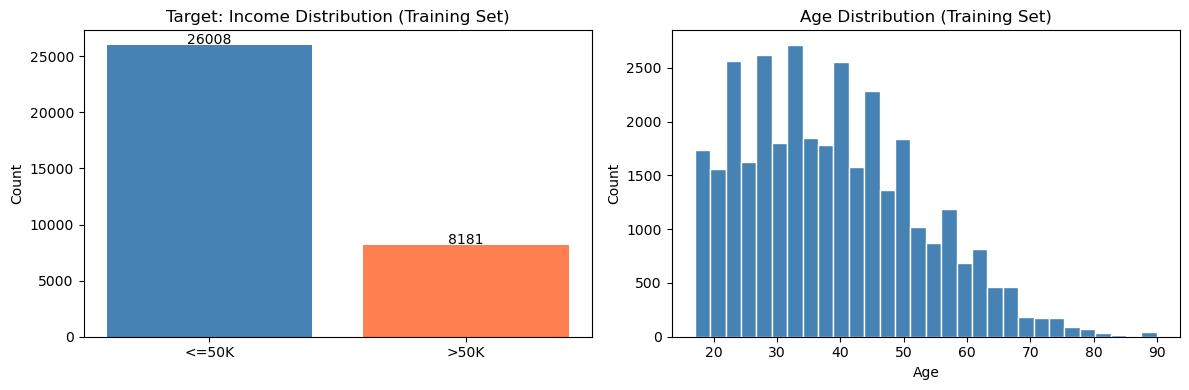

Chart saved.


In [7]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

income_counts = df_train['income'].value_counts()
axes[0].bar(income_counts.index, income_counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Target: Income Distribution (Training Set)')
axes[0].set_ylabel('Count')
for i, v in enumerate(income_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center')

# Age distribution
axes[1].hist(df_train['age'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Age Distribution (Training Set)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved.')

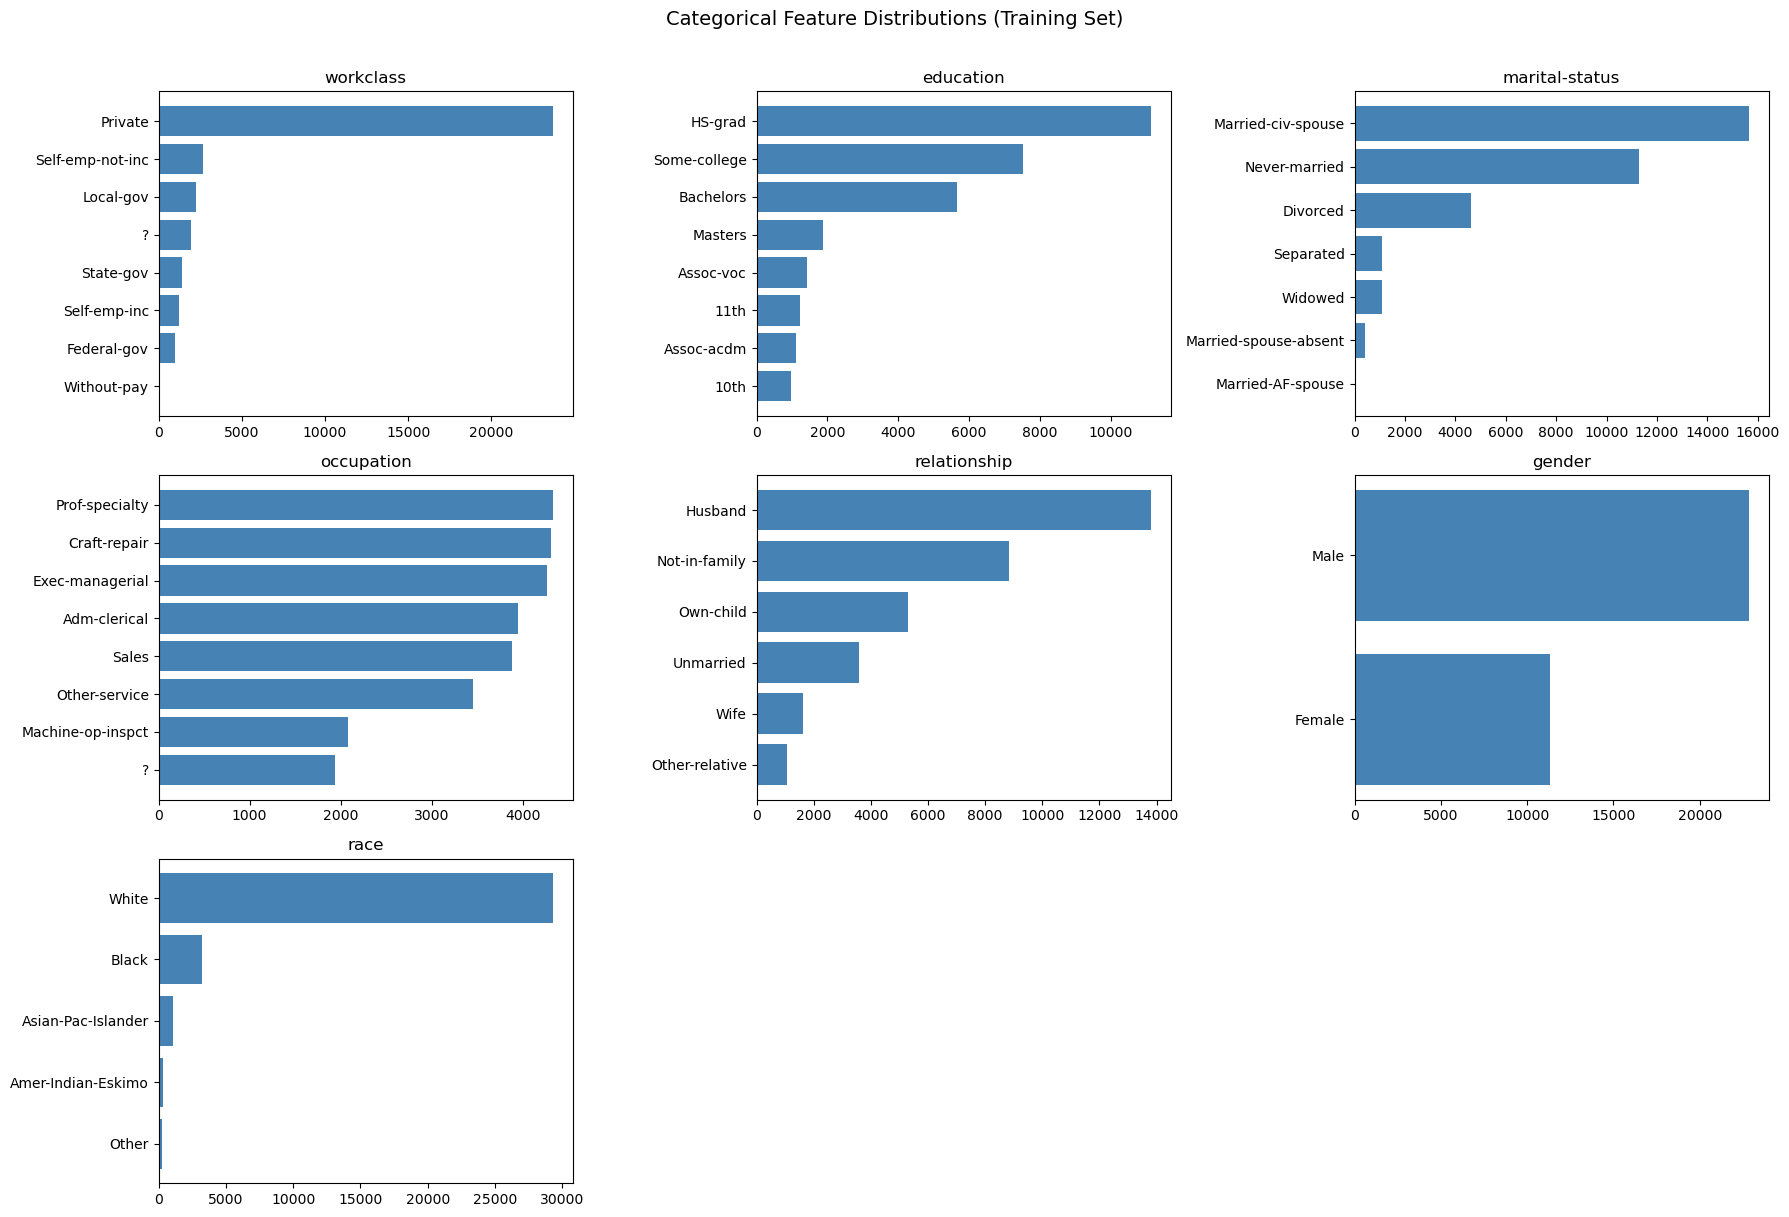

In [8]:
# Categorical feature exploration
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'gender', 'race']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_train[col].value_counts().head(8)
    axes[i].barh(counts.index, counts.values, color='steelblue')
    axes[i].set_title(f'{col}')
    axes[i].invert_yaxis()

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions (Training Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=100, bbox_inches='tight')
plt.show()

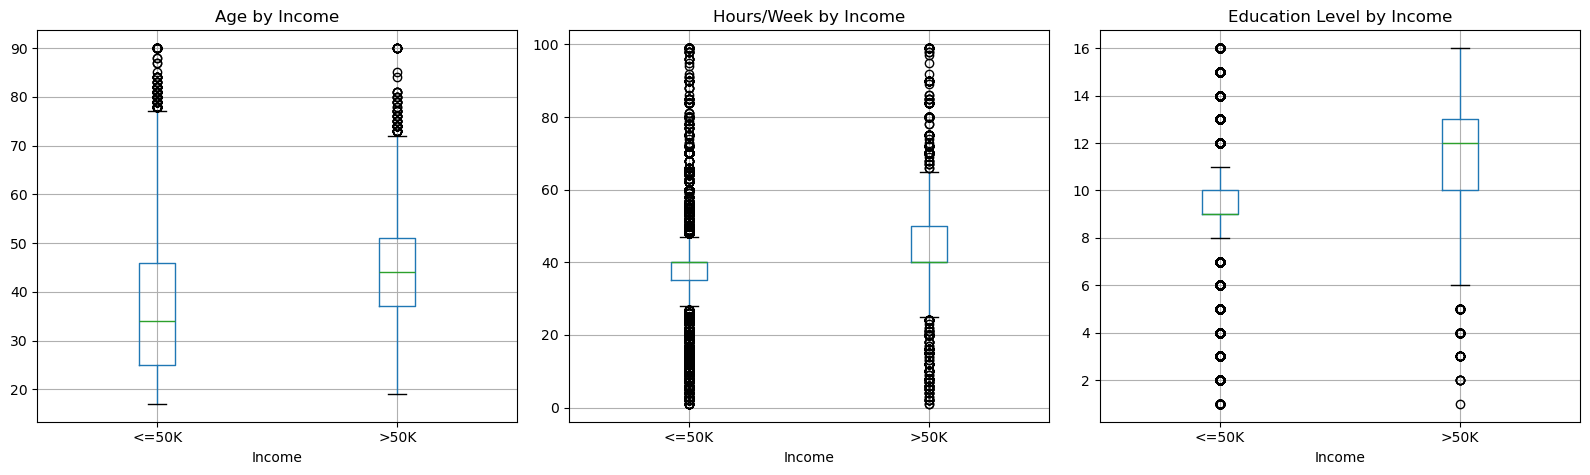

In [9]:
# Income by key features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age by income
df_train.boxplot(column='age', by='income', ax=axes[0])
axes[0].set_title('Age by Income')
axes[0].set_xlabel('Income')

# Hours per week by income
df_train.boxplot(column='hours-per-week', by='income', ax=axes[1])
axes[1].set_title('Hours/Week by Income')
axes[1].set_xlabel('Income')

# Education num by income
df_train.boxplot(column='educational-num', by='income', ax=axes[2])
axes[2].set_title('Education Level by Income')
axes[2].set_xlabel('Income')

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_income_features.png', dpi=100, bbox_inches='tight')
plt.show()

Data Cleaning

In [10]:
# Data cleaning on copy of training data
df_clean = df_train.copy()

print('=== BEFORE Cleaning ===')
print('Sample rows with ? values:')
print(df_clean[df_clean['workclass'] == '?'][['age','workclass','occupation','native-country','income']].head(5))

# Replace '?' with NaN
df_clean.replace('?', np.nan, inplace=True)

# Fill NaN with mode from training set
cols_with_missing = ['workclass', 'occupation', 'native-country']
fill_values = {}
for col in cols_with_missing:
    mode_val = df_clean[col].mode()[0]
    fill_values[col] = mode_val
    df_clean[col].fillna(mode_val, inplace=True)
    print(f'Filled "{col}" NaN with mode: "{mode_val}"')

print(f'\nRemaining nulls after cleaning: {df_clean.isnull().sum().sum()}')

=== BEFORE Cleaning ===
Sample rows with ? values:
       age workclass occupation native-country income
17212   19         ?          ?  United-States  <=50K
9312    32         ?          ?  United-States  <=50K
12616   47         ?          ?  United-States  <=50K
2547    51         ?          ?          South  <=50K
27636   73         ?          ?  United-States  <=50K
Filled "workclass" NaN with mode: "Private"
Filled "occupation" NaN with mode: "Prof-specialty"
Filled "native-country" NaN with mode: "United-States"

Remaining nulls after cleaning: 0


In [11]:
print('=== AFTER Cleaning — No More ? / NaN ===')
print(df_clean[['workclass','occupation','native-country']].isnull().sum())
print()
print('workclass value counts (? gone):')
print(df_clean['workclass'].value_counts())

=== AFTER Cleaning — No More ? / NaN ===
workclass         0
occupation        0
native-country    0
dtype: int64

workclass value counts (? gone):
workclass
Private             25635
Self-emp-not-inc     2681
Local-gov            2239
State-gov            1383
Self-emp-inc         1209
Federal-gov          1016
Without-pay            16
Never-worked           10
Name: count, dtype: int64


In [12]:
numeric_cols = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

print('=== BEFORE Scaling ===')
print(df_clean[numeric_cols].describe().loc[['min','max','mean']])

# Apply MinMax scaling
scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

print('\n=== AFTER Min-Max Scaling (range now 0 to 1) ===')
print(df_scaled[numeric_cols].describe().loc[['min','max','mean']])

=== BEFORE Scaling ===
       age     fnlwgt  educational-num  capital-gain  capital-loss  \
min  17.00   12285.00             1.00          0.00          0.00   
max  90.00 1484705.00            16.00      99999.00       4356.00   
mean 38.71  189651.77            10.08       1050.98         89.10   

      hours-per-week  
min             1.00  
max            99.00  
mean           40.48  

=== AFTER Min-Max Scaling (range now 0 to 1) ===
      age  fnlwgt  educational-num  capital-gain  capital-loss  hours-per-week
min  0.00    0.00             0.00          0.00          0.00            0.00
max  1.00    1.00             1.00          1.00          1.00            1.00
mean 0.30    0.12             0.61          0.01          0.02            0.40


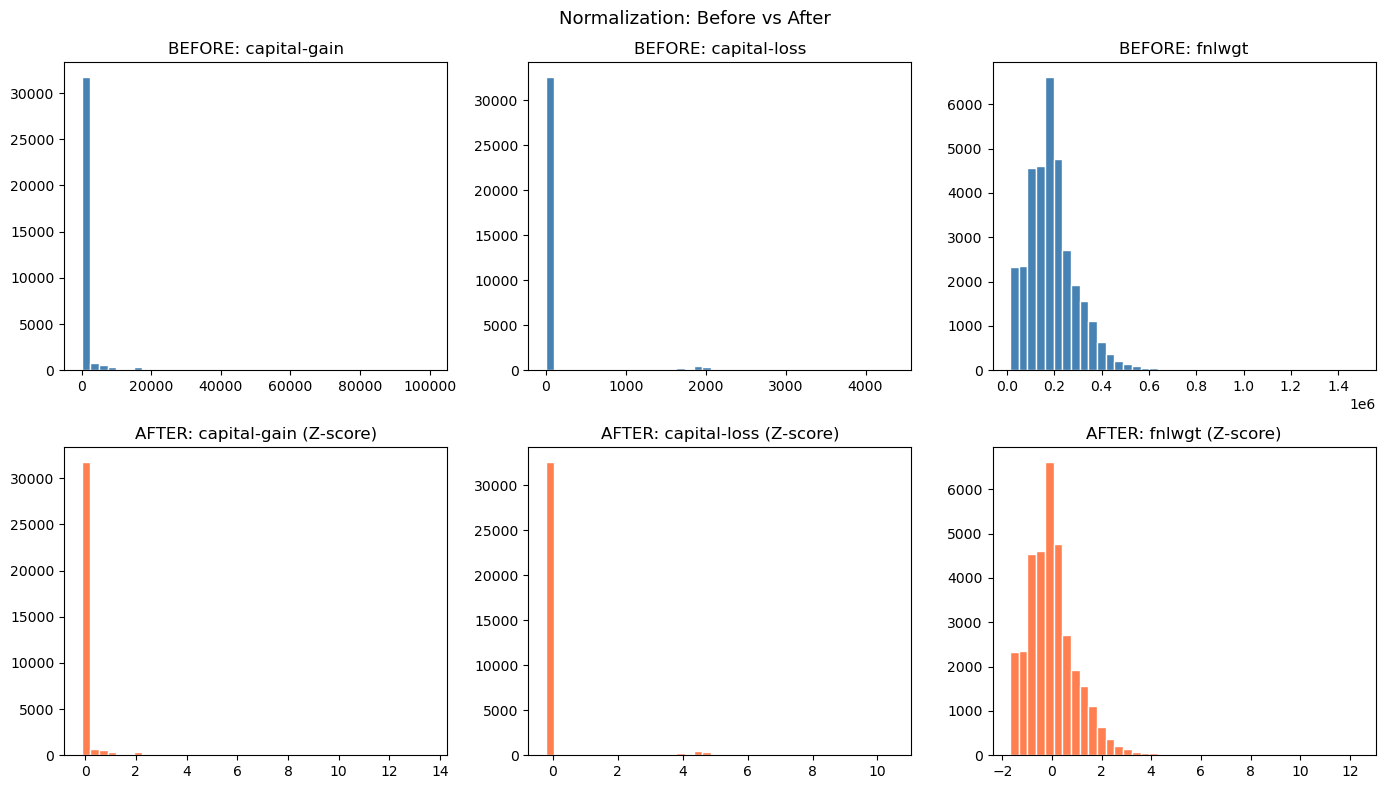

Mean after normalization (should be ~0):
capital-gain   -0.00
capital-loss   -0.00
fnlwgt         -0.00
dtype: float64
Std after normalization (should be ~1):
capital-gain   1.00
capital-loss   1.00
fnlwgt         1.00
dtype: float64


In [13]:
# Visualize skewness BEFORE normalization
skewed_cols = ['capital-gain', 'capital-loss', 'fnlwgt']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(skewed_cols):
    axes[0, i].hist(df_clean[col], bins=40, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'BEFORE: {col}')

# Apply StandardScaler (Z-score normalization)
std_scaler = StandardScaler()
df_normalized = df_scaled.copy()
df_normalized[skewed_cols] = std_scaler.fit_transform(df_clean[skewed_cols])

for i, col in enumerate(skewed_cols):
    axes[1, i].hist(df_normalized[col], bins=40, color='coral', edgecolor='white')
    axes[1, i].set_title(f'AFTER: {col} (Z-score)')

plt.suptitle('Normalization: Before vs After', fontsize=13)
plt.tight_layout()
plt.savefig('normalization_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print('Mean after normalization (should be ~0):')
print(df_normalized[skewed_cols].mean().round(4))
print('Std after normalization (should be ~1):')
print(df_normalized[skewed_cols].std().round(4))

In [14]:
df_encoded = df_normalized.copy()

print('=== BEFORE Label Encoding ===')
print(df_encoded[['gender', 'income']].head(5))

# Label encode binary columns
le = LabelEncoder()
binary_cols = ['gender', 'income']
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col} mapping: {mapping}')

print('\n=== AFTER Label Encoding ===')
print(df_encoded[['gender', 'income']].head(5))

=== BEFORE Label Encoding ===
       gender income
38865    Male  <=50K
17212  Female  <=50K
9312     Male  <=50K
15512    Male  <=50K
23576    Male  <=50K
  gender mapping: {'Female': np.int32(0), 'Male': np.int32(1)}
  income mapping: {'<=50K': np.int32(0), '>50K': np.int32(1)}

=== AFTER Label Encoding ===
       gender  income
38865       1       0
17212       0       0
9312        1       0
15512       1       0
23576       1       0


In [15]:
ohe_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

print(f'=== BEFORE One-Hot Encoding ===')
print(f'Shape: {df_encoded.shape}')
print(df_encoded[ohe_cols].head(3))

# One-Hot Encode
df_ohe = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

print(f'\n=== AFTER One-Hot Encoding ===')
print(f'Shape: {df_ohe.shape} (columns expanded from {df_encoded.shape[1]} to {df_ohe.shape[1]})')
print('New columns added (sample):')
new_cols = [c for c in df_ohe.columns if any(c.startswith(cat) for cat in ohe_cols)]
print(new_cols[:15], '...')

=== BEFORE One-Hot Encoding ===
Shape: (34189, 15)
      workclass     education      marital-status        occupation  \
38865   Private       HS-grad       Never-married  Transport-moving   
17212   Private  Some-college       Never-married    Prof-specialty   
9312    Private       HS-grad  Married-civ-spouse    Prof-specialty   

        relationship   race native-country  
38865  Not-in-family  White  United-States  
17212      Own-child  White  United-States  
9312         Husband  Black  United-States  

=== AFTER One-Hot Encoding ===
Shape: (34189, 98) (columns expanded from 15 to 98)
New columns added (sample):
['educational-num', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm'] ...


In [16]:
df_feat = df_ohe.copy()

# NOTE: age and hours-per-week are scaled (0-1). Use original df_clean for engineering then re-scale.
# For clarity, we reconstruct from original training values:
df_feat_check = df_clean.copy()
df_feat_check.replace('?', np.nan, inplace=True)
for col in cols_with_missing:
    df_feat_check[col].fillna(fill_values[col], inplace=True)

# Feature 1: capital_net = capital.gain - capital.loss
df_feat['capital_net'] = df_feat_check['capital-gain'] - df_feat_check['capital-loss']
print('Feature 1 — capital_net (capital gain minus capital loss):')
print(df_feat['capital_net'].describe())

# Feature 2: age_group — bin age into life stages
df_feat['age_group'] = pd.cut(
    df_feat_check['age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['Young', 'EarlyCareer', 'MidCareer', 'LateCareer', 'Senior']
)
df_feat['age_group'] = LabelEncoder().fit_transform(df_feat['age_group'].astype(str))
print('\nFeature 2 — age_group value counts:')
print(df_feat['age_group'].value_counts())

# Feature 3: is_high_hours — binary flag for people working more than 45 hrs/week
df_feat['is_high_hours'] = (df_feat_check['hours-per-week'] > 45).astype(int)
print('\nFeature 3 — is_high_hours (>45 hrs/week):')
print(df_feat['is_high_hours'].value_counts())

print(f'\nFinal dataset shape after feature engineering: {df_feat.shape}')

Feature 1 — capital_net (capital gain minus capital loss):
count   34189.00
mean      961.88
std      7305.89
min     -4356.00
25%         0.00
50%         0.00
75%         0.00
max     99999.00
Name: capital_net, dtype: float64

Feature 2 — age_group value counts:
age_group
2    11711
0     8878
4     6687
1     5658
3     1255
Name: count, dtype: int64

Feature 3 — is_high_hours (>45 hrs/week):
is_high_hours
0    26616
1     7573
Name: count, dtype: int64

Final dataset shape after feature engineering: (34189, 101)


In [17]:
summary = {
    'Stage': [
        'Raw Dataset',
        'After Train/Test Split (train)',
        'After Cleaning (? -> mode)',
        'After Scaling (MinMax)',
        'After Normalization (Z-score)',
        'After Label Encoding',
        'After One-Hot Encoding',
        'After Feature Engineering'
    ],
    'Rows': [
        df_raw.shape[0],
        df_train.shape[0],
        df_clean.shape[0],
        df_scaled.shape[0],
        df_normalized.shape[0],
        df_encoded.shape[0],
        df_ohe.shape[0],
        df_feat.shape[0]
    ],
    'Columns': [
        df_raw.shape[1],
        df_train.shape[1],
        df_clean.shape[1],
        df_scaled.shape[1],
        df_normalized.shape[1],
        df_encoded.shape[1],
        df_ohe.shape[1],
        df_feat.shape[1]
    ],
    'Missing Values': [
        df_raw.replace('?', np.nan).isnull().sum().sum(),
        df_train.replace('?', np.nan).isnull().sum().sum(),
        df_clean.isnull().sum().sum(),
        df_scaled.isnull().sum().sum(),
        df_normalized.isnull().sum().sum(),
        df_encoded.isnull().sum().sum(),
        df_ohe.isnull().sum().sum(),
        df_feat.isnull().sum().sum()
    ]
}

summary_df = pd.DataFrame(summary)
print('=== Dataset Transformation Summary ===')
print(summary_df.to_string(index=False))

=== Dataset Transformation Summary ===
                         Stage  Rows  Columns  Missing Values
                   Raw Dataset 48842       15            6465
After Train/Test Split (train) 34189       15            4452
    After Cleaning (? -> mode) 34189       15               0
        After Scaling (MinMax) 34189       15               0
 After Normalization (Z-score) 34189       15               0
          After Label Encoding 34189       15               0
        After One-Hot Encoding 34189       98               0
     After Feature Engineering 34189      101               0


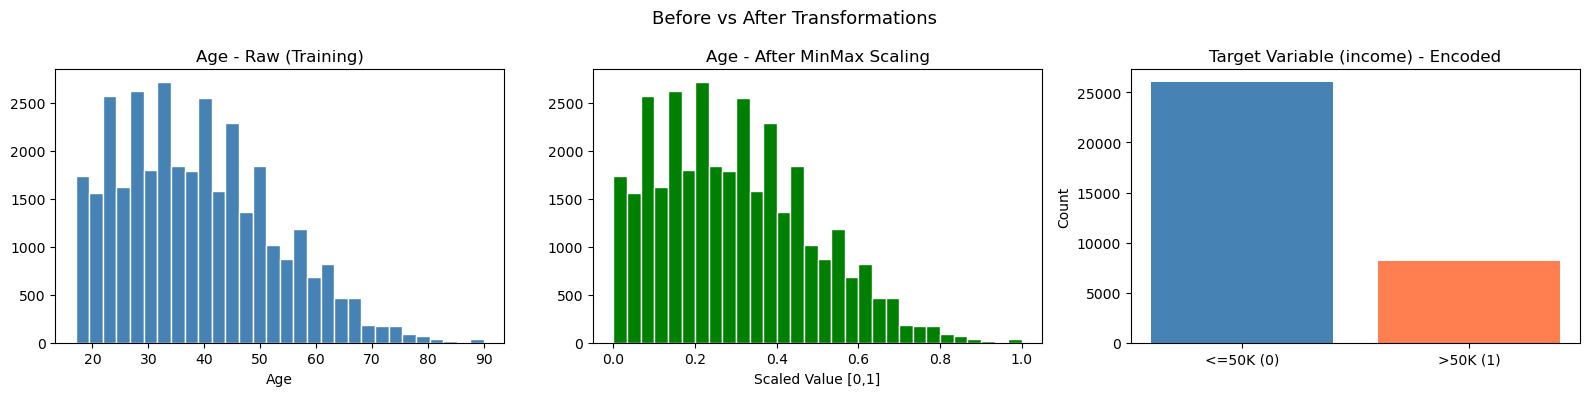

In [18]:
# Visual comparison: age column before and after scaling
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Before scaling
axes[0].hist(df_clean['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age - Raw (Training)')
axes[0].set_xlabel('Age')

# After MinMax scaling
axes[1].hist(df_scaled['age'], bins=30, color='green', edgecolor='white')
axes[1].set_title('Age - After MinMax Scaling')
axes[1].set_xlabel('Scaled Value [0,1]')

# Income class balance
income_map = {'<=50K': 0, '>50K': 1}
income_encoded = df_train['income'].map(income_map)
axes[2].bar(['<=50K (0)', '>50K (1)'], income_encoded.value_counts().sort_index().values,
            color=['steelblue', 'coral'])
axes[2].set_title('Target Variable (income) - Encoded')
axes[2].set_ylabel('Count')

plt.suptitle('Before vs After Transformations', fontsize=13)
plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

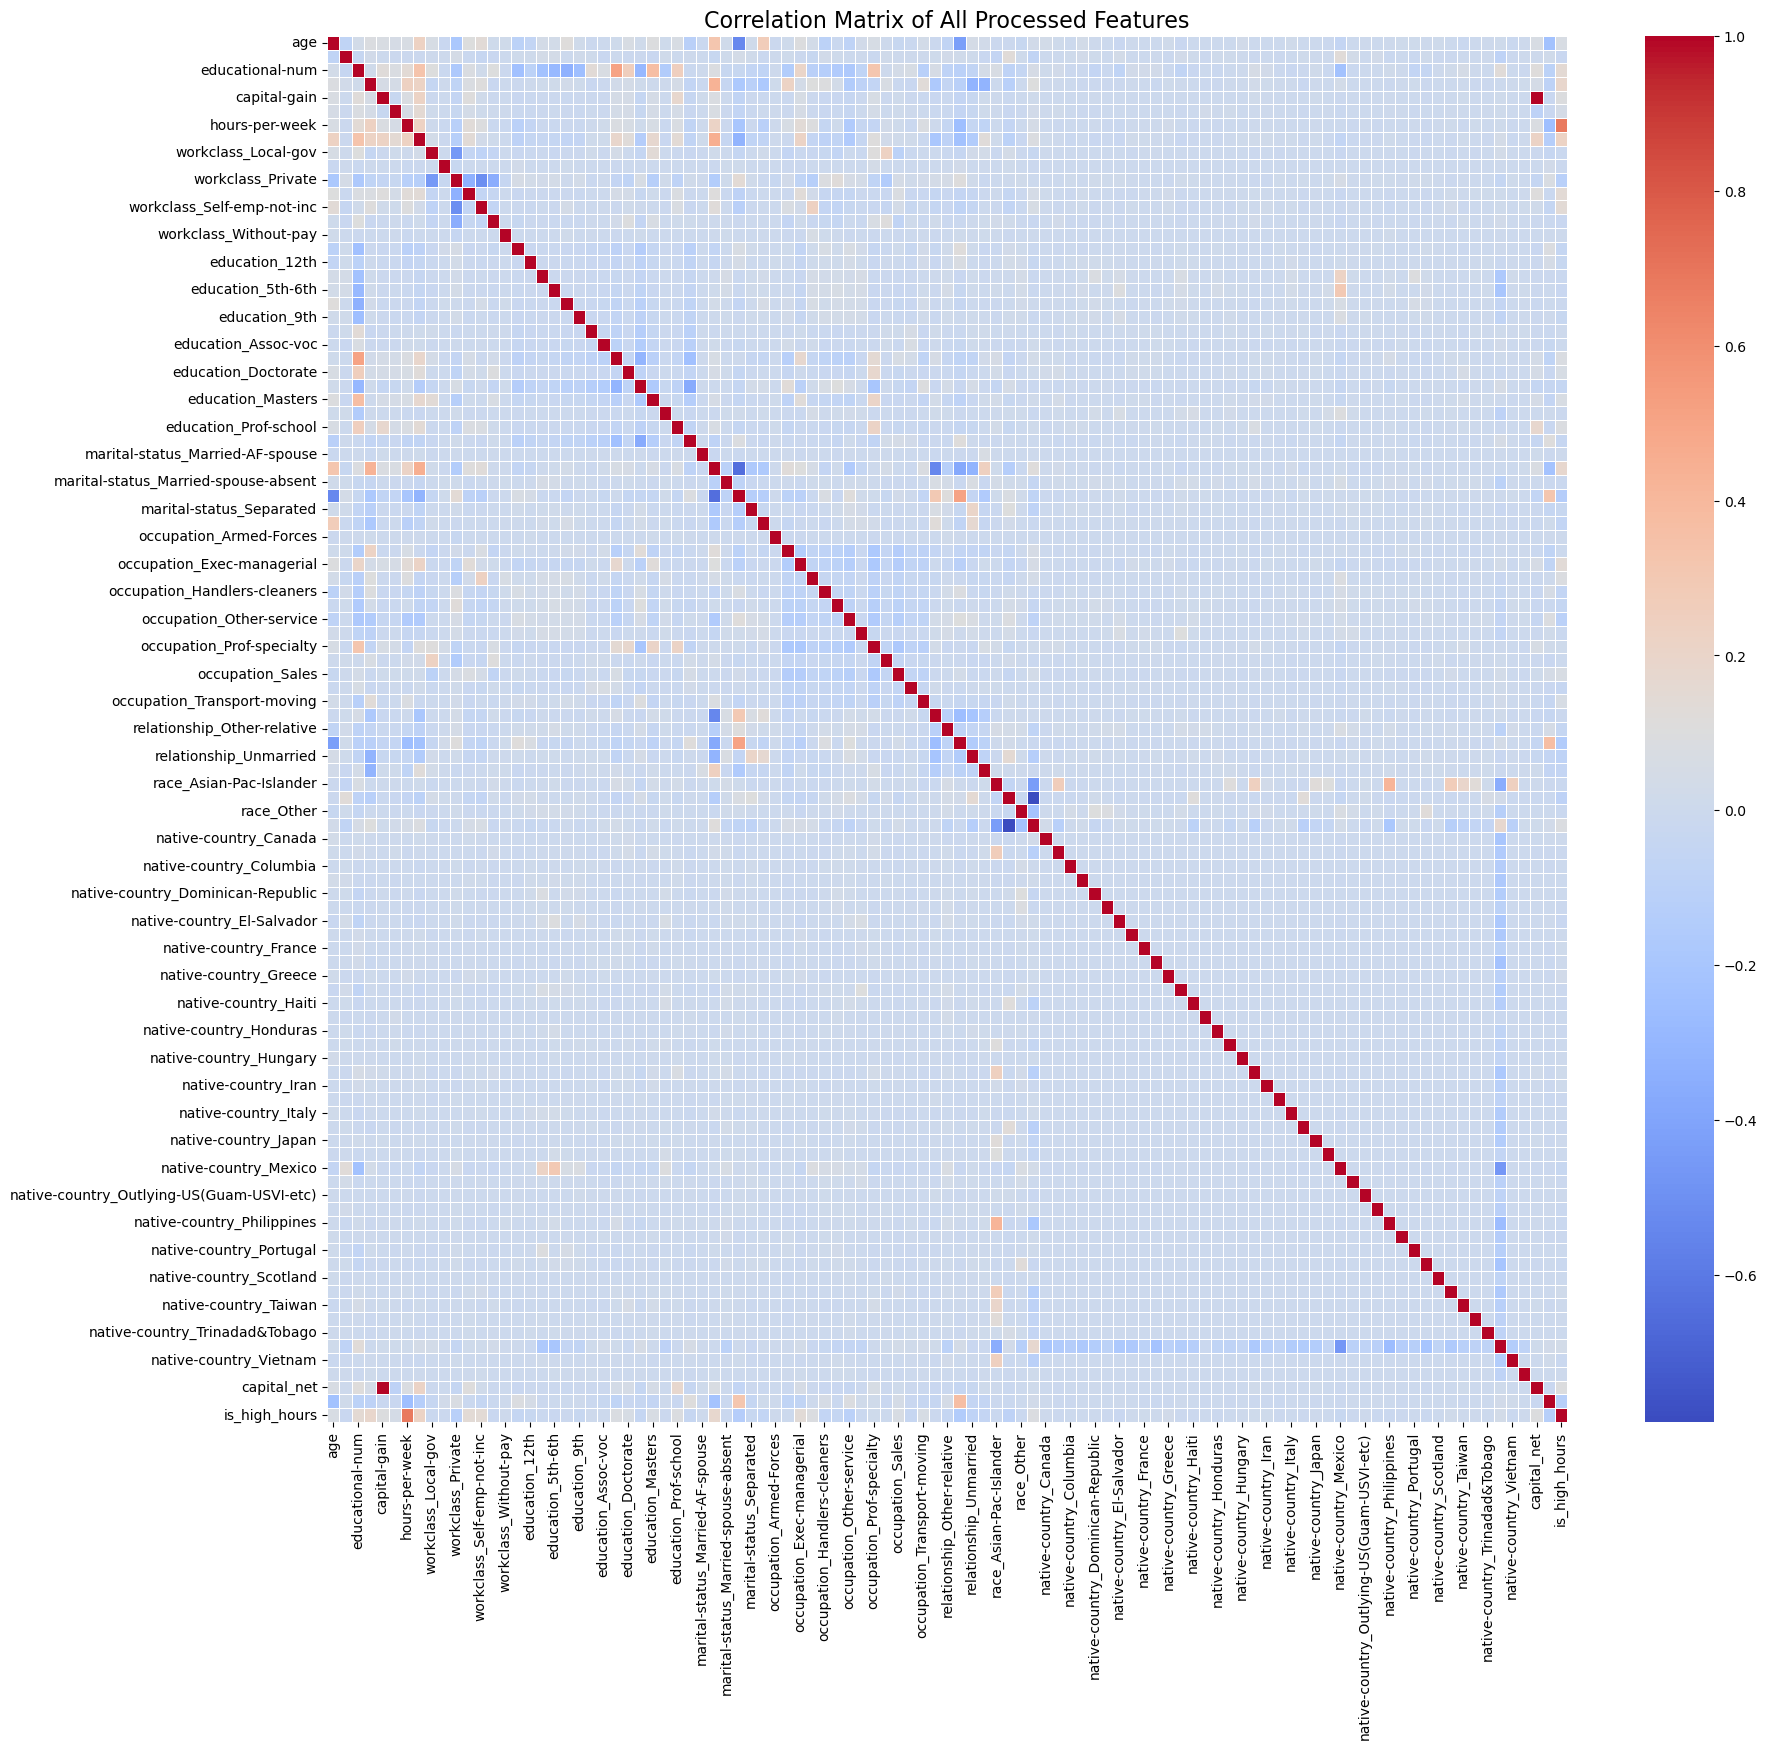


=== Correlations with Income ===
Top 10 Positive Correlations:
income                              1.00
marital-status_Married-civ-spouse   0.45
educational-num                     0.33
age                                 0.23
hours-per-week                      0.22
capital-gain                        0.22
is_high_hours                       0.22
gender                              0.22
occupation_Exec-managerial          0.22
capital_net                         0.21
Name: income, dtype: float64

Top 10 Negative Correlations:
occupation_Handlers-cleaners   -0.09
race_Black                     -0.09
workclass_Private              -0.12
age_group                      -0.13
education_HS-grad              -0.13
relationship_Unmarried         -0.15
occupation_Other-service       -0.16
relationship_Not-in-family     -0.19
relationship_Own-child         -0.22
marital-status_Never-married   -0.32
Name: income, dtype: float64


In [19]:
plt.figure(figsize=(20, 18))
sns.heatmap(df_feat.corr(), cmap='coolwarm', fmt=".2f", annot=False, linewidths=.5)
plt.title('Correlation Matrix of All Processed Features', fontsize=16)
plt.show()


# Calculate correlation matrix
correlation_matrix = df_feat.corr()

# Extract correlations with 'income' and sort them
income_correlations = correlation_matrix['income'].sort_values(ascending=False)

print('\n=== Correlations with Income ===')
print('Top 10 Positive Correlations:')
print(income_correlations.head(10))

print('\nTop 10 Negative Correlations:')
print(income_correlations.tail(10))


In [20]:
# Export clean training data
df_feat.to_csv('adult_income_clean_train.csv', index=False)
print(f'Clean training dataset saved: adult_income_clean_train.csv')
print(f'Shape: {df_feat.shape}')

# Save untouched test set
df_test_untouched.to_csv('adult_income_test_raw.csv', index=False)
print(f'\nUntouched test dataset saved: adult_income_test_raw.csv')
print(f'Shape: {df_test_untouched.shape}')

print('\nFirst 3 rows of clean training data:')
df_feat.head(3)

Clean training dataset saved: adult_income_clean_train.csv
Shape: (34189, 101)

Untouched test dataset saved: adult_income_test_raw.csv
Shape: (14653, 15)

First 3 rows of clean training data:


,age,fnlwgt,educational-num,gender,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Never-worked,...,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,capital_net,age_group,is_high_hours
38865,0.05,1.21,0.53,1,-0.14,-0.22,0.60,0,False,False,...,False,False,False,False,True,False,False,0,4,1
17212,0.03,-1.31,0.60,0,-0.14,-0.22,0.09,0,False,False,...,False,False,False,False,True,False,False,0,4,0
9312,0.21,1.44,0.53,1,-0.14,-0.22,0.45,0,False,False,...,False,False,False,False,True,False,False,0,0,0
